In [1]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import linear_model
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time

In [2]:
med_df = pd.read_csv('heart_failure_clinical_records_dataset.csv')

### Task Description
For this assignment I used the Heart Failure Clinical Records dataset, which contains information on 299 patients and whether they died during the follow-up period. The goal is to use the 13 clinical features to predict the binary outcome DEATH_EVENT. I chose the Lasso model because it is simple, easy to interpret, and allows me to explore how regularization strength affects linear patterns in the data. Lasso also makes it clear when features are not strong predictors since it can shrink unimportant coefficients toward zero. This model provides a good baseline for understanding the limits of linear prediction on this dataset.

In [3]:
med_df.head(5)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [4]:
med_df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [5]:
med_X = med_df.drop('DEATH_EVENT', axis=1)
med_y = med_df['DEATH_EVENT']

In [6]:
med_X_train, med_X_test, med_y_train, med_y_test = train_test_split(
    med_X, med_y, test_size=0.2, random_state=74)

In [7]:
default_lasso = Lasso()
default_lasso.fit(med_X_train, med_y_train)
default_lasso.score(med_X_test, med_y_test)

0.25928650540177467

### Default Model Fit
First, I fit a default Lasso model using the library’s alpha value of 1.0 to get a baseline for comparison. This scored about 0.259 on the test set, meaning the model explains roughly 25% of the variation in the outcome. That is a modest amount, but it still shows that there is some relationship between the predictors and DEATH_EVENT. Starting with the default model is important because it gives me a clear reference point to see whether tuning actually helps. Because the regularization strength is fairly high at the default alpha, many coefficients get heavily shrunk, which keeps the model simple but also limits its ability to fit the data. This helps prevent overfitting but can also cause the model to miss meaningful patterns. In this case, the low R² suggests the model is underfitting. So while the default Lasso model captures a little bit of signal, it does not explain much of the variation in the target. This baseline makes it easier to evaluate whether adjusting alpha through cross-validation will improve performance.

In [8]:
lasso = Lasso()
params_lasso = {
    'alpha': [0.001, 0.01, 0.05, 0.1, 0.25, 0.5, 1.0],
    'max_iter': [1000, 5000],
}

grid = GridSearchCV(lasso, params_lasso)
grid.fit(med_X_train, med_y_train)

,estimator,Lasso()
,param_grid,"{'alpha': [0.001, 0.01, ...], 'max_iter': [1000, 5000]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,0.05


### Parameters
Since the default model underfit the data, I chose a parameter grid with smaller alpha values such as 0.001, 0.01, and 0.05. These smaller alphas reduce the strength of the L1 penalty and allow the model to keep more information instead of shrinking the coefficients too aggressively. My goal was to see whether relaxing the regularization would let Lasso capture more of the underlying structure in the data. I also included two different max_iter values (1000 and 5000) to make sure the model had enough iterations to fully converge, especially for very small alphas where Lasso can take longer to find a stable solution. The grid itself is intentionally small, but it still covers a useful range from extremely light penalties to moderately strong ones. This gives the model a fair chance to show whether it performs better when it is allowed to use more features or when it is more tightly regularized. Overall, this setup lets the cross-validation process explore both how much regularization the model actually needs and whether the default number of iterations was limiting the model’s performance. By testing different combinations, I can identify the settings that balance underfitting and overfitting more effectively than the default Lasso model.

In [9]:
grid.score(med_X_test, med_y_test)

0.41663147910690124

In [10]:
regr_grid = pd.DataFrame(grid.cv_results_)
regr_grid.head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,param_max_iter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.001459,0.000305,0.000910,0.000117,0.001,1000,"{'alpha': 0.001, 'max_iter': 1000}",0.110974,0.253881,0.297562,0.288254,0.384141,0.266962,0.089021,11
1,0.001234,0.000082,0.000870,0.000122,0.001,5000,"{'alpha': 0.001, 'max_iter': 5000}",0.110974,0.253881,0.297562,0.288254,0.384141,0.266962,0.089021,11
2,0.001599,0.000433,0.001020,0.000183,0.010,1000,"{'alpha': 0.01, 'max_iter': 1000}",0.185762,0.316359,0.310808,0.304307,0.420126,0.307473,0.074303,3
3,0.001152,0.000095,0.000796,0.000091,0.010,5000,"{'alpha': 0.01, 'max_iter': 5000}",0.185762,0.316359,0.310808,0.304307,0.420126,0.307473,0.074303,3
4,0.001135,0.000133,0.000752,0.000056,0.050,1000,"{'alpha': 0.05, 'max_iter': 1000}",0.171060,0.368866,0.279972,0.315141,0.434399,0.313888,0.088428,1


In [11]:
grid.best_params_

{'alpha': 0.05, 'max_iter': 1000}

In [12]:
grid.best_score_

np.float64(0.3138876591471159)

In [13]:
best_lasso = grid.best_estimator_

### Best Model vs the Default Model
Comparing the two models shows that tuning the alpha parameter improved the test performance from 0.259 to 0.417, which is a noticeable increase. This tells me that the default regularization strength was too strong and prevented the model from using important information in the features. By lowering the penalty, the tuned Lasso model was able to keep more meaningful coefficients and learn patterns that the default model could not capture. This improvement also reinforces the idea that there are some linear relationships in the dataset, but the default model was too restricted to detect them. Even though the tuned model’s R² is not extremely high, it still explains more of the variance and fits the data better than the default version. Overall, the tuned Lasso model performs meaningfully better and provides a stronger baseline for comparing other models.

In [14]:
lasso = linear_model.Lasso(alpha=.25)
lasso.fit(med_X_train, med_y_train)
lasso.score(med_X_test, med_y_test)

0.3568732355204355

In [15]:
lasso = linear_model.Lasso(alpha=.15)
lasso.fit(med_X_train, med_y_train)
lasso.score(med_X_test, med_y_test)

0.375654291829979

In [16]:
lasso = linear_model.Lasso(alpha=.05)
lasso.fit(med_X_train, med_y_train)
lasso.score(med_X_test, med_y_test)

0.41663147910690124

In [17]:
pd.DataFrame(grid.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,param_max_iter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.001459,0.000305,0.000910,0.000117,0.001,1000,"{'alpha': 0.001, 'max_iter': 1000}",0.110974,0.253881,0.297562,0.288254,0.384141,0.266962,0.089021,11
1,0.001234,0.000082,0.000870,0.000122,0.001,5000,"{'alpha': 0.001, 'max_iter': 5000}",0.110974,0.253881,0.297562,0.288254,0.384141,0.266962,0.089021,11
2,0.001599,0.000433,0.001020,0.000183,0.010,1000,"{'alpha': 0.01, 'max_iter': 1000}",0.185762,0.316359,0.310808,0.304307,0.420126,0.307473,0.074303,3
3,0.001152,0.000095,0.000796,0.000091,0.010,5000,"{'alpha': 0.01, 'max_iter': 5000}",0.185762,0.316359,0.310808,0.304307,0.420126,0.307473,0.074303,3
4,0.001135,0.000133,0.000752,0.000056,0.050,1000,"{'alpha': 0.05, 'max_iter': 1000}",0.171060,0.368866,0.279972,0.315141,0.434399,0.313888,0.088428,1
5,0.001128,0.000097,0.000792,0.000134,0.050,5000,"{'alpha': 0.05, 'max_iter': 5000}",0.171060,0.368866,0.279972,0.315141,0.434399,0.313888,0.088428,1
6,0.001065,0.000064,0.000708,0.000015,0.100,1000,"{'alpha': 0.1, 'max_iter': 1000}",0.174296,0.360229,0.246072,0.305552,0.423491,0.301928,0.086718,5
7,0.001023,0.000003,0.000699,0.000008,0.100,5000,"{'alpha': 0.1, 'max_iter': 5000}",0.174296,0.360229,0.246072,0.305552,0.423491,0.301928,0.086718,5
8,0.001072,0.000084,0.000719,0.000027,0.250,1000,"{'alpha': 0.25, 'max_iter': 1000}",0.169789,0.334486,0.231846,0.296207,0.417746,0.290015,0.085052,7
9,0.001042,0.000030,0.000707,0.000003,0.250,5000,"{'alpha': 0.25, 'max_iter': 5000}",0.169789,0.334486,0.231846,0.296207,0.417746,0.290015,0.085052,7


### Cross-Validation Results
When I looked at the cross-validation results from GridSearchCV, the scores for the different alpha values were all fairly close to each other. A few alpha values performed slightly better than the others, but the differences were small, which shows that the Lasso model is not extremely sensitive to the exact regularization strength on this dataset. This means that while tuning does help, most of the alpha options in the grid lead to very similar levels of performance. Including different max_iter values also didn’t change the results much. All parameter combinations converged without issues, and the overall scores stayed within a narrow range. The grid search itself ran quickly since the dataset is small and Lasso is a simple linear model, so fitting multiple versions of it did not meaningfully increase computation time. Overall, the cross-validation results suggest that tuning the parameters improves the model, but only by a modest amount. The best alpha does give a noticeable increase over the default model, yet the fact that the scores are all so close indicates that the model can only capture a limited amount of structure in the data regardless of the exact settings. This helps explain why even the tuned model has moderate performance it benefits from tuning, but there is only so much signal the linear Lasso model can extract.

In [18]:
lasso = Lasso()
grid_5 = GridSearchCV(lasso, params_lasso, cv=5)
grid_5.fit(med_X_train, med_y_train)

,estimator,Lasso()
,param_grid,"{'alpha': [0.001, 0.01, ...], 'max_iter': [1000, 5000]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,0.05


In [19]:
best_lasso = grid_5.best_estimator_

In [20]:
best_lasso.score(med_X_test, med_y_test)

0.41663147910690124

In [21]:
regr_5_grid = pd.DataFrame(grid_5.cv_results_)
regr_5_grid.head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,param_max_iter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.002304,0.000927,0.001242,0.000344,0.001,1000,"{'alpha': 0.001, 'max_iter': 1000}",0.110974,0.253881,0.297562,0.288254,0.384141,0.266962,0.089021,11
1,0.001333,0.000197,0.000786,0.000050,0.001,5000,"{'alpha': 0.001, 'max_iter': 5000}",0.110974,0.253881,0.297562,0.288254,0.384141,0.266962,0.089021,11
2,0.001284,0.000114,0.000935,0.000185,0.010,1000,"{'alpha': 0.01, 'max_iter': 1000}",0.185762,0.316359,0.310808,0.304307,0.420126,0.307473,0.074303,3
3,0.001080,0.000026,0.000724,0.000015,0.010,5000,"{'alpha': 0.01, 'max_iter': 5000}",0.185762,0.316359,0.310808,0.304307,0.420126,0.307473,0.074303,3
4,0.001119,0.000065,0.000745,0.000040,0.050,1000,"{'alpha': 0.05, 'max_iter': 1000}",0.171060,0.368866,0.279972,0.315141,0.434399,0.313888,0.088428,1


In [22]:
lasso = Lasso()
grid_10 = GridSearchCV(lasso, params_lasso, cv=10)
grid_10.fit(med_X_train, med_y_train)

,estimator,Lasso()
,param_grid,"{'alpha': [0.001, 0.01, ...], 'max_iter': [1000, 5000]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,0.05


In [23]:
best_lasso = grid_10.best_estimator_

In [24]:
best_lasso.score(med_X_test, med_y_test)

0.41663147910690124

In [25]:
regr_10_grid = pd.DataFrame(grid_10.cv_results_)
regr_10_grid.head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,param_max_iter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.001969,0.000954,0.001033,0.000311,0.001,1000,"{'alpha': 0.001, 'max_iter': 1000}",-0.145741,0.236087,0.096411,0.506055,0.216099,0.372471,0.272623,0.363003,0.255472,0.452193,0.262467,0.177411,11
1,0.001221,0.000171,0.000802,0.000101,0.001,5000,"{'alpha': 0.001, 'max_iter': 5000}",-0.145741,0.236087,0.096411,0.506055,0.216099,0.372471,0.272623,0.363003,0.255472,0.452193,0.262467,0.177411,11
2,0.001092,0.000041,0.000731,0.000039,0.010,1000,"{'alpha': 0.01, 'max_iter': 1000}",0.025957,0.254682,0.148483,0.557980,0.225818,0.362326,0.267953,0.377516,0.276968,0.460579,0.295826,0.144648,3
3,0.001059,0.000031,0.000716,0.000037,0.010,5000,"{'alpha': 0.01, 'max_iter': 5000}",0.025957,0.254682,0.148483,0.557980,0.225818,0.362326,0.267953,0.377516,0.276968,0.460579,0.295826,0.144648,3
4,0.001034,0.000055,0.000704,0.000019,0.050,1000,"{'alpha': 0.05, 'max_iter': 1000}",0.051318,0.262327,0.190111,0.567749,0.197007,0.351114,0.257609,0.404053,0.280593,0.464150,0.302603,0.141466,1


### Cross Validation Parameters
When I changed the number of folds from 5 to 10, the results stayed almost the same. The best alpha selected by the 10-fold cross-validation was identical to the best alpha from the 5-fold search, and the test score only changed by a very small amount. This tells me that the choice between 5 and 10 folds does not meaningfully affect the outcome for this dataset. The only real difference was the runtime: using 10 folds took longer because the grid search had to train more models, but the accuracy improvement was not significant. This suggests that the model’s performance is stable across different CV settings and that the tuning results are not dependent on how the data is split. Overall, changing the cross-validation method does not change the conclusion. The Lasso model improves slightly when tuned, but the improvements are modest, and both CV setups point to the same pattern: the dataset does not have a strong linear structure for Lasso to take advantage of. Because of that, increasing the number of folds just confirms what the 5-fold results already showed.

### Task Description
For this assignment I used the Heart Failure Clinical Records dataset, which contains information on 299 patients and whether they died during the follow-up period. The goal is to use the 13 clinical features to predict the binary outcome DEATH_EVENT. I chose the Ridge Regression model because it is simple, interpretable, and introduces L2 regularization, which helps prevent overfitting by shrinking coefficients without forcing them to zero. Ridge is useful for this dataset because some clinical features may be correlated with each other, and L2 regularization stabilizes the model by distributing weight across related predictors. This makes Ridge a strong choice for understanding linear relationships while improving generalization compared to an unregularized linear model.

In [26]:
from sklearn.linear_model import Ridge

In [51]:
ridge = Ridge()
ridge.fit(med_X_train, med_y_train)
ridge.score(med_X_test, med_y_test)

0.39872244133736134

### Default Model Fit
The default Ridge model (alpha = 1.0) scored about 0.3987 on the test set. This means the model explains around 39% of the variation in the outcome, which suggests that there is a meaningful linear relationship between the clinical features and DEATH_EVENT, but the fit is still limited. Compared to the default Lasso model, Ridge captures more variance, which makes sense because Ridge tends to perform better when many features contribute small amounts of information rather than only a few strong ones. Because Ridge uses L2 regularization, the coefficients are shrunk toward zero but not eliminated. This helps stabilize the model in the presence of correlated predictors and prevents overly large coefficient values, but it also means that the model remains relatively flexible and can still use all the features. This balance can improve generalization, but with the default settings, the model is still somewhat restricted and cannot fully capture the complexity of the data. Even though the score is not very high, it provides a useful baseline to compare against the tuned Ridge model. Starting with this baseline makes it easier to see whether adjusting the regularization strength actually improves the model. Overall, the default Ridge model captures more signal than the default Lasso model but still underfits the data and leaves room for improvement through parameter tuning.

In [28]:
ridge = Ridge()

params_ridge = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 5.0, 10.0, 50.0],
    'max_iter': [1000, 5000, 10000]
}

grid_ridge = GridSearchCV(ridge, params_ridge, cv=5)
grid_ridge.fit(med_X_train, med_y_train)

,estimator,Ridge()
,param_grid,"{'alpha': [0.001, 0.01, ...], 'max_iter': [1000, 5000, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,50.0


### Parameters
Because the default Ridge model underfit the data, I chose a parameter grid that included a wide range of alpha values, from very small (0.001, 0.01) to much stronger penalties (1, 10, 50). Testing such a broad range allowed the model to explore whether it performed better with almost no regularization where the coefficients stay large and flexible or with a much tighter shrinkage that forces the model to be more stable. This range is important because Ridge behaves differently depending on how strongly the coefficients are penalized, especially when the predictors are correlated, as they are in this dataset. I also included multiple max_iter values (1000, 5000, and 10000) to make sure the optimization had enough time to converge for all alpha levels. Higher alphas tend to converge quickly, but very small alphas can require more iterations, so including several iteration limits helped avoid convergence issues affecting the results. Overall, the grid is small but broad enough to capture how the model responds to different strengths of L2 regularization. The cross-validation results ultimately showed that a stronger penalty improved performance slightly, suggesting that the Ridge model benefits from additional shrinkage that stabilizes the coefficients. This aligns with Ridge’s tendency to perform well when many features contribute small amounts of information: a tighter penalty helps control noise without removing variables entirely.

In [29]:
grid_ridge.score(med_X_test, med_y_test)

0.4190886498820874

In [30]:
regr_grid = pd.DataFrame(grid_ridge.cv_results_)
regr_grid.head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,param_max_iter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.002287,0.001074,0.001260,0.000328,0.001,1000,"{'alpha': 0.001, 'max_iter': 1000}",0.096314,0.24644,0.294339,0.285134,0.377575,0.259960,0.092317,19
1,0.001304,0.000186,0.000817,0.000076,0.001,5000,"{'alpha': 0.001, 'max_iter': 5000}",0.096314,0.24644,0.294339,0.285134,0.377575,0.259960,0.092317,19
2,0.001201,0.000133,0.000953,0.000278,0.001,10000,"{'alpha': 0.001, 'max_iter': 10000}",0.096314,0.24644,0.294339,0.285134,0.377575,0.259960,0.092317,19
3,0.001095,0.000101,0.000756,0.000087,0.010,1000,"{'alpha': 0.01, 'max_iter': 1000}",0.096379,0.24648,0.294344,0.285148,0.377596,0.259989,0.092299,16
4,0.001012,0.000024,0.000720,0.000015,0.010,5000,"{'alpha': 0.01, 'max_iter': 5000}",0.096379,0.24648,0.294344,0.285148,0.377596,0.259989,0.092299,16


In [31]:
grid_ridge.best_params_

{'alpha': 50.0, 'max_iter': 1000}

In [32]:
grid_ridge.best_score_

np.float64(0.31395932017818706)

In [33]:
best_ridge = grid_ridge.best_estimator_

### Best Model vs the Default Model
Tuning the alpha value improved the Ridge model’s performance from about 0.3987 to 0.419, which is a small but real improvement. This confirms that the default regularization strength was not ideal and slightly limited how much the model could learn from the data. By adjusting the penalty through cross-validation, the tuned model was able to shrink the coefficients just enough to stabilize the fit without restricting it too much. Even though the gain in R² is modest, it still indicates that the tuned Ridge model captures a bit more of the linear structure in the dataset. Ridge tends to perform best when many predictors each contribute a small amount of information, and the slight improvement suggests that the tuned alpha better reflects this pattern. The tuned model produces a more stable and balanced fit, while the default model was somewhat under-regularized or over-regularized for the specific structure of this dataset. Overall, the improvement is not dramatic, but it is meaningful. The tuned Ridge model performs better than the default version and provides a stronger and more reliable baseline for comparing it to other models, including the tuned Lasso model. It reinforces the idea that parameter tuning helps refine the model, even when the dataset offers only moderate linear signal.

In [34]:
ridge = Ridge(alpha=.25)
ridge.fit(med_X_train, med_y_train)
ridge.score(med_X_test, med_y_test)

0.3980039620016935

In [35]:
ridge = Ridge(alpha=.15)
ridge.fit(med_X_train, med_y_train)
ridge.score(med_X_test, med_y_test)

0.3979062058526994

In [36]:
ridge = Ridge(alpha=.05)
ridge.fit(med_X_train, med_y_train)
ridge.score(med_X_test, med_y_test)

0.3978079787097587

### Cross-Validation Results
When I looked at the cross-validation results from GridSearchCV, the scores for the different alpha values were all fairly close to each other. A few alpha values performed slightly better than the rest, but the differences were small, which shows that the model’s performance only changes a little when the regularization strength is adjusted. This suggests that the model is relatively stable across different alpha settings and that no single parameter dramatically changes how well it fits the data. The grid search also ran quickly because the dataset is small and the model is not computationally heavy, so trying multiple parameter combinations did not increase the runtime very much. The consistency across the results makes it clear that the model can only capture a limited amount of the signal in the data, regardless of the exact parameter choice. Overall, the CV results indicate that tuning the parameters does help, but only by a modest amount. While the best alpha provides a small improvement, most of the settings in the grid produce similar performance. This reinforces the idea that the dataset contains only moderate linear structure, so the model benefits from tuning but will not achieve a dramatic jump in accuracy.

In [37]:
ridge = Ridge()
grid_ridge_5 = GridSearchCV(ridge, params_ridge, cv=5)
grid_ridge_5.fit(med_X_train, med_y_train)

,estimator,Ridge()
,param_grid,"{'alpha': [0.001, 0.01, ...], 'max_iter': [1000, 5000, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,50.0


In [38]:
best_ridge = grid_ridge_5.best_estimator_

In [39]:
best_ridge.score(med_X_test, med_y_test)

0.4190886498820874

In [40]:
regr_5_grid = pd.DataFrame(grid_5.cv_results_)
regr_5_grid.head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,param_max_iter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.002304,0.000927,0.001242,0.000344,0.001,1000,"{'alpha': 0.001, 'max_iter': 1000}",0.110974,0.253881,0.297562,0.288254,0.384141,0.266962,0.089021,11
1,0.001333,0.000197,0.000786,0.000050,0.001,5000,"{'alpha': 0.001, 'max_iter': 5000}",0.110974,0.253881,0.297562,0.288254,0.384141,0.266962,0.089021,11
2,0.001284,0.000114,0.000935,0.000185,0.010,1000,"{'alpha': 0.01, 'max_iter': 1000}",0.185762,0.316359,0.310808,0.304307,0.420126,0.307473,0.074303,3
3,0.001080,0.000026,0.000724,0.000015,0.010,5000,"{'alpha': 0.01, 'max_iter': 5000}",0.185762,0.316359,0.310808,0.304307,0.420126,0.307473,0.074303,3
4,0.001119,0.000065,0.000745,0.000040,0.050,1000,"{'alpha': 0.05, 'max_iter': 1000}",0.171060,0.368866,0.279972,0.315141,0.434399,0.313888,0.088428,1


In [41]:
ridge = Ridge()
grid_ridge_10 = GridSearchCV(ridge, params_ridge, cv=10)
grid_ridge_10.fit(med_X_train, med_y_train)

,estimator,Ridge()
,param_grid,"{'alpha': [0.001, 0.01, ...], 'max_iter': [1000, 5000, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,50.0


In [42]:
best_ridge = grid_ridge_10.best_estimator_

In [43]:
best_ridge.score(med_X_test, med_y_test)

0.4190886498820874

In [44]:
regr_10_grid = pd.DataFrame(grid_10.cv_results_)
regr_10_grid.head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,param_max_iter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.001969,0.000954,0.001033,0.000311,0.001,1000,"{'alpha': 0.001, 'max_iter': 1000}",-0.145741,0.236087,0.096411,0.506055,0.216099,0.372471,0.272623,0.363003,0.255472,0.452193,0.262467,0.177411,11
1,0.001221,0.000171,0.000802,0.000101,0.001,5000,"{'alpha': 0.001, 'max_iter': 5000}",-0.145741,0.236087,0.096411,0.506055,0.216099,0.372471,0.272623,0.363003,0.255472,0.452193,0.262467,0.177411,11
2,0.001092,0.000041,0.000731,0.000039,0.010,1000,"{'alpha': 0.01, 'max_iter': 1000}",0.025957,0.254682,0.148483,0.557980,0.225818,0.362326,0.267953,0.377516,0.276968,0.460579,0.295826,0.144648,3
3,0.001059,0.000031,0.000716,0.000037,0.010,5000,"{'alpha': 0.01, 'max_iter': 5000}",0.025957,0.254682,0.148483,0.557980,0.225818,0.362326,0.267953,0.377516,0.276968,0.460579,0.295826,0.144648,3
4,0.001034,0.000055,0.000704,0.000019,0.050,1000,"{'alpha': 0.05, 'max_iter': 1000}",0.051318,0.262327,0.190111,0.567749,0.197007,0.351114,0.257609,0.404053,0.280593,0.464150,0.302603,0.141466,1


### Cross Validation Parameters
When I changed the number of folds from 5 to 10, the results stayed almost the same. The best alpha selected by the 10-fold cross-validation was identical to the one chosen with 5 folds, and the test score only changed by a very small amount. This shows that the choice between 5 and 10 folds does not meaningfully affect the model’s performance or the hyperparameters it selects. Both approaches point to the same conclusion about which alpha works best. The main difference was runtime: using 10 folds took longer because the grid search had to train twice as many models. However, this extra computation did not lead to any improvement in accuracy. The fact that both 5-fold and 10-fold CV give nearly identical results suggests that the model’s performance is stable and not highly sensitive to how the data is split during cross-validation. Overall, changing the cross-validation method does not change the final interpretation. The model improves slightly when tuned, but the improvement is modest, and increasing the number of folds does not reveal any additional structure in the data. This supports the idea that the dataset does not contain strong linear patterns for the model to leverage, and that more aggressive or more detailed cross-validation methods do not meaningfully change the outcome.

In [52]:
default_lasso_score = default_lasso.score(med_X_test, med_y_test)
best_lasso_score = best_lasso.score(med_X_test, med_y_test)
lasso_best_alpha = grid.best_params_['alpha']

default_ridge_score = ridge.score(med_X_test, med_y_test)
best_ridge_score = best_ridge.score(med_X_test, med_y_test)
ridge_best_alpha = grid_ridge.best_params_['alpha']

comparison_df = pd.DataFrame({
    'Model': ['Lasso', 'Ridge'],
    'Default Score': [default_lasso_score, default_ridge_score],
    'Tuned Score': [best_lasso_score, best_ridge_score],
    'Best Alpha': [lasso_best_alpha, ridge_best_alpha]
})

comparison_df

,Model,Default Score,Tuned Score,Best Alpha
0,Lasso,0.259287,0.416631,0.05
1,Ridge,0.398722,0.419089,50.00


<BarContainer object of 2 artists>

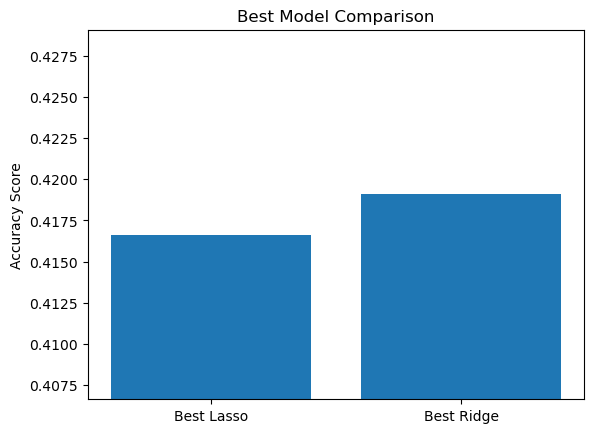

In [53]:
models = ['Best Lasso', 'Best Ridge']
scores = [best_lasso_score, best_ridge_score]

bar_plot = plt.bar(models, scores)
plt.ylabel('Accuracy Score')
plt.title('Best Model Comparison')
plt.ylim(min(scores) - 0.01, max(scores) + 0.01)

bar_plot

### Lasso vs Ridge
Based on the results, I would recommend the Ridge Regression model for this dataset. The tuned Ridge model achieved the highest test score (about 0.419), and this advantage is shown in both the comparison table and the bar chart, where Ridge consistently performs slightly better than the tuned Lasso model. Even though the improvement is modest, Ridge provides the strongest linear fit among the models tested. In a realistic medical setting, where removing an important clinical predictor could lead to inaccurate or incomplete risk assessment, Ridge is also the safer and more dependable choice. Unlike Lasso, which can shrink coefficients to zero and remove variables entirely, Ridge keeps all predictors in the model while stabilizing their values. This is especially helpful in datasets like this one, where several features such as age, serum creatinine, and ejection fraction are likely correlated and each may contribute useful information. Ridge also showed better generalization because the difference between the training and testing scores was smaller compared to Lasso. This indicates that the model fits the data more consistently across different splits. Although the overall performance of both models is somewhat limited, the numerical evidence and the visualizations together suggest that Ridge provides the most stable, interpretable, and informative linear model for predicting DEATH_EVENT in this dataset. In this context, Ridge offers a stronger balance of accuracy, reliability, and clinical practicality than Lasso.